<a href="https://colab.research.google.com/github/aadyai623/armcx5-pan-cancer-survival/blob/main/armcx5-pan-cancer-survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=76005ad7152cc7e3fe1583053e92f8ebe5067b6366ecacfcee784582ca50be15
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [6]:
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('survival.tsv', sep='\t')
df.head()

,sample,patient,OS,OS.time,gene expression RNAseq - STAR - FPKM-UQ: ARMCX5,data
0,TCGA-69-7979-01A,TCGA-69-7979,0,408,high,3.344
1,TCGA-64-1676-01A,TCGA-64-1676,0,1728,high,3.114
2,TCGA-78-7161-01A,TCGA-78-7161,1,291,high,2.996
3,TCGA-35-5375-01A,TCGA-35-5375,0,264,high,2.983
4,TCGA-44-5645-01B,TCGA-44-5645,0,852,high,2.928


In [8]:
grp_col = [c for c in df.columns if 'gene expression' in c][0]
df = df.dropna(subset=['OS', 'OS.time', grp_col]).copy()

high = df[df[grp_col] == 'high']
low = df[df[grp_col] == 'low']

print(f"High group: {len(high)} patients")
print(f"Low group: {len(low)} patients")

High group: 290 patients
Low group: 286 patients


In [9]:
result = logrank_test(
    high['OS.time'].tolist(), low['OS.time'].tolist(),
    event_observed_A=high['OS'].tolist(), event_observed_B=low['OS'].tolist()
)
print(f"p-value = {result.p_value:.4f}")
print(f"test statistic = {result.test_statistic:.3f}")

p-value = 0.2832
test statistic = 1.152


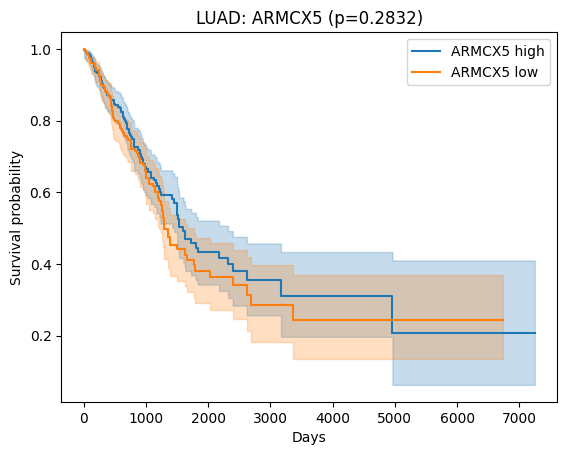

In [10]:
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_high.fit(high['OS.time'], high['OS'], label='ARMCX5 high')
kmf_low.fit(low['OS.time'], low['OS'], label='ARMCX5 low')

ax = kmf_high.plot_survival_function()
kmf_low.plot_survival_function(ax=ax)
plt.title(f'LUAD: ARMCX5 (p={result.p_value:.4f})')
plt.xlabel('Days')
plt.ylabel('Survival probability')
plt.show()

In [13]:
files = {
    'LUAD': 'survival.tsv',
    'OV': 'survival (1).tsv',
    'KIRC': 'survival (2).tsv',
    'SKCM': 'survival (3).tsv',
    'UCEC': 'survival (4).tsv',
}

results_table = []

for cancer_type, filename in files.items():
    d = pd.read_csv(filename, sep='\t')
    gcol = [c for c in d.columns if 'gene expression' in c][0]
    d = d.dropna(subset=['OS', 'OS.time', gcol]).copy()

    h = d[d[gcol] == 'high']
    l = d[d[gcol] == 'low']

    r = logrank_test(
        h['OS.time'].tolist(), l['OS.time'].tolist(),
        event_observed_A=h['OS'].tolist(), event_observed_B=l['OS'].tolist()
    )

    results_table.append({
        'Cancer Type': cancer_type,
        'N (high)': len(h),
        'N (low)': len(l),
        'p-value': round(r.p_value, 4),
        'Significant': 'Yes' if r.p_value < 0.05 else 'No'
    })

summary = pd.DataFrame(results_table)
summary

,Cancer Type,N (high),N (low),p-value,Significant
0,LUAD,290,286,0.2832,No
1,OV,154,153,0.2232,No
2,KIRC,302,303,0.9071,No
3,SKCM,228,231,0.1768,No
4,UCEC,279,290,0.4356,No


In [14]:
summary.to_csv('armcx5_results.csv', index=False)